In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

In [2]:
qnumber = 3
qc = QuantumCircuit(qnumber)
qc.h(0)  # Hadamard
qc.cx(0, 1)  # CNOT
qc.h(2)  # Hadamard

display(qc.draw())

┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
     ┌───┐└───┘
q_2: ┤ H ├─────
     └───┘

In [3]:
state = Statevector.from_instruction(qc)
ideal_dist = state.probabilities_dict()

display(state.draw("latex"))

<IPython.core.display.Latex object>

## Obwód użytkownika

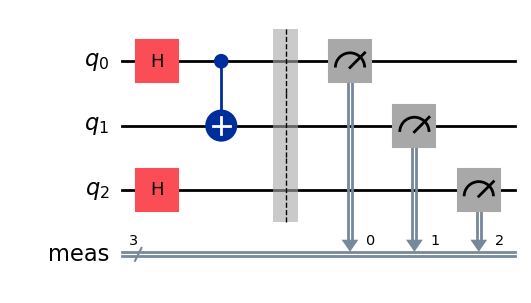

In [4]:
qc_measure = qc.copy()
qc_measure.measure_all()

display(qc_measure.draw("mpl"))

## Obwód otrzymany z transpilatora

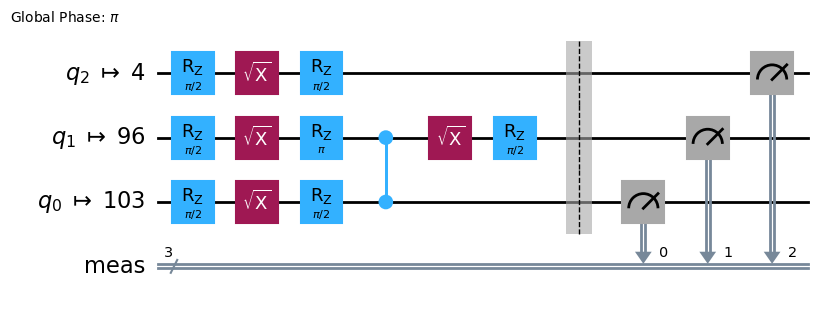

In [5]:
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit.transpiler import generate_preset_pass_manager

backend = FakeFez()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(qc_measure)

display(isa_circuit.draw("mpl"))